# Analysis and plotting: abundant-data all-dynamics, multi-topology benchmark

This notebook performs **no model training**. It analyzes the persistent cache written by
`experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed.ipynb`.

The analysis is intentionally aligned with the final single-shot broad benchmark:

- 195 fixed environment instances;
- 150 matched unstructured Barabási--Albert environments covering all six dynamics;
- 45 structured HK / FJ / nonlinear-influence mechanism environments;
- 3 learned identifier seeds per environment;
- matched no-control, uniform, and true-graph reference policies.

## Statistical treatment

The three learning seeds are first averaged **within each environment instance**. The environment,
not the neural-network seed, is the unit of the principal comparison.

For the generic 5-by-5 topology/opinion design, uncertainty is estimated with a **crossed bootstrap**:
topology seeds and opinion seeds are sampled independently with replacement, preserving the crossed
design. For structured family summaries with only five environment realizations, confidence intervals
use the Student-$t$ distribution rather than a hard-coded 1.96 multiplier.

The old “fraction of oracle advantage recovered” diagnostic is intentionally omitted. The
`true_graph` policy is treated as a **true-graph reference**, not as a globally optimal oracle.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr, t as student_t

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 280)
pd.set_option("display.max_rows", 240)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing opinion_dynamics/.")


REPO_ROOT = find_repo_root()
RESULTS_ROOT = REPO_ROOT / "opinion_dynamics" / "experiments" / "results"
RESULTS_DIR = RESULTS_ROOT / "experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed"
COMBINED_PATH = RESULTS_DIR / "combined_summary.csv"
COMPLETION_PATH = RESULTS_DIR / "COMPUTATION_COMPLETE.json"

if not COMBINED_PATH.exists():
    raise FileNotFoundError(
        f"Missing {COMBINED_PATH}. Run the abundant computation notebook/launcher first, "
        "then run the computation notebook once in non-worker mode to merge the cache."
    )

print("Repository root:", REPO_ROOT)
print("Results dir:", RESULTS_DIR)
print("Combined summary:", COMBINED_PATH)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_109212\3176548358.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Repository root: d:\Work\repos\RL\unknown_graph_networks
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed
Combined summary: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed\combined_summary.csv


## Plot style and export settings

`paper_bw` is the default for manuscript figures. All exported figures are written to the abundant
results directory in both PNG and PDF form.


In [2]:
PLOT_STYLE = "paper_bw"   # "paper_bw" or "explore"
SAVE_PNG = True
SAVE_PDF = True

if PLOT_STYLE not in {"paper_bw", "explore"}:
    raise ValueError(PLOT_STYLE)

PLOT_DIR = RESULTS_DIR / f"plots_{PLOT_STYLE}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def apply_plot_style(style: str) -> None:
    mpl.rcdefaults()
    common = {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
    if style == "paper_bw":
        common.update({
            "axes.grid": False,
            "axes.edgecolor": "0.15",
            "text.color": "0.1",
            "axes.labelcolor": "0.1",
            "xtick.color": "0.1",
            "ytick.color": "0.1",
        })
    else:
        common.update({"axes.grid": True, "grid.alpha": 0.22})
    mpl.rcParams.update(common)


apply_plot_style(PLOT_STYLE)

if PLOT_STYLE == "paper_bw":
    POLICY_STYLE = {
        "no control": {"color": "0.80", "marker": "x", "linestyle": ":", "hatch": ".."},
        "uniform": {"color": "0.58", "marker": "s", "linestyle": "--", "hatch": "//"},
        "learned": {"color": "0.18", "marker": "o", "linestyle": "-", "hatch": "xx"},
        "true graph": {"color": "0.38", "marker": "^", "linestyle": "-.", "hatch": "\\\\"},
    }
else:
    POLICY_STYLE = {
        "no control": {"color": "#7f7f7f", "marker": "x", "linestyle": ":", "hatch": ".."},
        "uniform": {"color": "#d08c28", "marker": "s", "linestyle": "--", "hatch": "//"},
        "learned": {"color": "#2b6cb0", "marker": "o", "linestyle": "-", "hatch": "xx"},
        "true graph": {"color": "#3b8f55", "marker": "^", "linestyle": "-.", "hatch": "\\\\"},
    }

DYNAMICS_LABELS = {
    "laplacian": "Linear",
    "coca": "COCA",
    "hegselmannkrause": "HK",
    "friedkinjohnsen": "FJ",
    "nonlinearinfluence": "Nonlinear",
    "repulsion": "Repulsion",
}
DYNAMICS_ORDER = [
    "laplacian", "coca", "hegselmannkrause", "friedkinjohnsen",
    "nonlinearinfluence", "repulsion",
]
STRUCTURED_ORDER = ["hegselmannkrause", "friedkinjohnsen", "nonlinearinfluence"]

FAMILY_LABELS = {
    "ring_bridge": "Ring bridge",
    "paired_bridge": "Paired bridge",
    "dense_weak_bridge": "Dense weak bridge",
    "asymmetric_broadcast": "Asymmetric broadcast",
    "dual_broadcast": "Dual broadcast",
    "split_broadcast": "Split broadcast",
}

def save_figure(fig: plt.Figure, stem: str) -> None:
    if SAVE_PNG:
        fig.savefig(PLOT_DIR / f"{stem}.png")
    if SAVE_PDF:
        fig.savefig(PLOT_DIR / f"{stem}.pdf")


print("Plot style:", PLOT_STYLE)
print("Plot output:", PLOT_DIR)


Plot style: paper_bw
Plot output: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed\plots_paper_bw


## Load and validate the abundant cache

The computation notebook writes one combined table containing the three matched baselines and three
learned seeds for every environment. This cell validates the complete 195-environment / 585-learned-run
design and discovers the active cache hash used by the rollout artifacts.


In [3]:
def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


combined_df = pd.read_csv(COMBINED_PATH)

required_columns = {
    "environment_id", "scenario_class", "family", "dynamics", "policy",
    "learning_seed", "mean_end", "mean_over_trajectory",
}
missing_columns = sorted(required_columns - set(combined_df.columns))
if missing_columns:
    raise RuntimeError(f"combined_summary.csv is missing columns: {missing_columns}")

baseline_df = combined_df[combined_df["policy"].isin(["no_control", "uniform", "true_graph"])].copy()
learned_df = combined_df[combined_df["policy"] == "learned_abundant_nonlinear"].copy()

EXPECTED_ENVS = 195
EXPECTED_LEARNED = 585
EXPECTED_BASELINES = EXPECTED_ENVS * 3
EXPECTED_COMBINED = EXPECTED_BASELINES + EXPECTED_LEARNED

assert combined_df["environment_id"].nunique() == EXPECTED_ENVS
assert len(learned_df) == EXPECTED_LEARNED
assert len(baseline_df) == EXPECTED_BASELINES
assert len(combined_df) == EXPECTED_COMBINED
assert not baseline_df.duplicated(["environment_id", "policy"]).any()
assert not learned_df.duplicated(["environment_id", "learning_seed"]).any()
assert learned_df.groupby("environment_id").size().eq(3).all()

# Discover the active cache directory. Prefer the global completion marker; fall
# back to selecting the cache hash containing all environment IDs.
STUDY_NAME = "abundant_all_dynamics_multitopology_multiseed"
CACHE_BASE = RESULTS_ROOT / "_trial_cache" / STUDY_NAME

CONFIG_HASH = None
if COMPLETION_PATH.exists():
    completion = read_json(COMPLETION_PATH)
    CONFIG_HASH = completion.get("config_hash")
    print("Completion marker:", completion.get("status"), "config", CONFIG_HASH)

if CONFIG_HASH is None:
    env_ids = set(combined_df["environment_id"].astype(str))
    candidates = []
    if CACHE_BASE.exists():
        for candidate in CACHE_BASE.iterdir():
            if not candidate.is_dir():
                continue
            present = sum((candidate / env_id).is_dir() for env_id in env_ids)
            candidates.append((present, candidate.name))
    if not candidates:
        raise FileNotFoundError(f"Could not discover abundant cache under {CACHE_BASE}")
    candidates.sort(reverse=True)
    if candidates[0][0] != EXPECTED_ENVS:
        raise RuntimeError(f"Best cache candidate contains only {candidates[0][0]}/{EXPECTED_ENVS} environments")
    CONFIG_HASH = candidates[0][1]
    print("Completion marker unavailable; discovered cache config:", CONFIG_HASH)

CACHE_ROOT = CACHE_BASE / str(CONFIG_HASH)
ENV_CACHE = {env_id: CACHE_ROOT / env_id for env_id in combined_df["environment_id"].unique()}
missing_cache_dirs = [env_id for env_id, path in ENV_CACHE.items() if not path.exists()]
if missing_cache_dirs:
    raise RuntimeError(f"Missing {len(missing_cache_dirs)} environment cache directories; first: {missing_cache_dirs[:5]}")

print("Cache validation passed.")
print("Distinct environments:", combined_df["environment_id"].nunique())
print("Baseline rows:", len(baseline_df))
print("Learned rows:", len(learned_df))
print("Combined rows:", len(combined_df))
print("Cache root:", CACHE_ROOT)

display(
    learned_df.groupby(["scenario_class", "dynamics"], as_index=False).size()
)


Completion marker: success config 7e75b33e99a91619
Cache validation passed.
Distinct environments: 195
Baseline rows: 585
Learned rows: 585
Combined rows: 1170
Cache root: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\abundant_all_dynamics_multitopology_multiseed\7e75b33e99a91619


,scenario_class,dynamics,size
0,structured_mechanism,friedkinjohnsen,45
1,structured_mechanism,hegselmannkrause,45
2,structured_mechanism,nonlinearinfluence,45
3,unstructured_random,coca,75
4,unstructured_random,friedkinjohnsen,75
5,unstructured_random,hegselmannkrause,75
6,unstructured_random,laplacian,75
7,unstructured_random,nonlinearinfluence,75
8,unstructured_random,repulsion,75


## Reconstruct environment-level paired results

The three learned seeds are averaged before any principal comparison. Baseline policies already have
one deterministic evaluation per environment. The resulting table is the main statistical unit used
below.


In [4]:
learned_env = (
    learned_df.groupby(
        ["environment_id", "scenario_class", "family", "dynamics", "topology_seed", "opinion_seed", "environment_seed"],
        dropna=False,
        as_index=False,
    )
    .agg(
        learned_final_mean=("mean_end", "mean"),
        learned_final_mean_seed_std=("mean_end", "std"),
        learned_mean_over_trajectory=("mean_over_trajectory", "mean"),
        learned_trajectory_seed_std=("mean_over_trajectory", "std"),
        model_over_identity=("model_over_identity", "mean"),
        train_mae=("train_mae", "mean"),
        identity_mae=("identity_mae", "mean"),
        A_MAE=("A_MAE", "mean"),
        A_Fro=("A_Fro", "mean"),
        v_static_L1=("v_static_L1", "mean"),
        fit_elapsed_s=("fit_elapsed_s", "mean"),
        fit_steps_run=("fit_steps_run", "mean"),
        train_pairs_total=("train_pairs_total", "mean"),
        learned_hub_budget_fraction=("mean_controlled_hub_budget_fraction", "mean"),
    )
)


def baseline_metric(policy: str, source: str, target: str) -> pd.DataFrame:
    return (
        baseline_df[baseline_df["policy"] == policy][["environment_id", source]]
        .rename(columns={source: target})
    )


env_level_df = learned_env.copy()
for policy, prefix in [("uniform", "uniform"), ("true_graph", "true_graph"), ("no_control", "no_control")]:
    env_level_df = env_level_df.merge(
        baseline_metric(policy, "mean_end", f"{prefix}_final_mean"),
        on="environment_id", how="left", validate="one_to_one",
    )
    env_level_df = env_level_df.merge(
        baseline_metric(policy, "mean_over_trajectory", f"{prefix}_mean_over_trajectory"),
        on="environment_id", how="left", validate="one_to_one",
    )

# Structured mechanism allocation diagnostics, when defined.
if "mean_controlled_hub_budget_fraction" in baseline_df.columns:
    for policy, prefix in [("uniform", "uniform"), ("true_graph", "true_graph")]:
        env_level_df = env_level_df.merge(
            baseline_metric(policy, "mean_controlled_hub_budget_fraction", f"{prefix}_hub_budget_fraction"),
            on="environment_id", how="left", validate="one_to_one",
        )

# Primary paired differences.
env_level_df["learned_minus_uniform_final"] = env_level_df["learned_final_mean"] - env_level_df["uniform_final_mean"]
env_level_df["learned_minus_uniform_trajectory"] = env_level_df["learned_mean_over_trajectory"] - env_level_df["uniform_mean_over_trajectory"]
env_level_df["learned_minus_true_graph_final"] = env_level_df["learned_final_mean"] - env_level_df["true_graph_final_mean"]
env_level_df["true_graph_minus_uniform_final"] = env_level_df["true_graph_final_mean"] - env_level_df["uniform_final_mean"]
env_level_df["learned_minus_no_control_final"] = env_level_df["learned_final_mean"] - env_level_df["no_control_final_mean"]

env_level_df.to_csv(RESULTS_DIR / "abundant_environment_level_results.csv", index=False)
learned_df.to_csv(RESULTS_DIR / "abundant_learned_seed_results.csv", index=False)
baseline_df.to_csv(RESULTS_DIR / "abundant_baseline_results.csv", index=False)

print("Environment-level rows:", len(env_level_df))
display(env_level_df.head().round(5))


Environment-level rows: 195


,environment_id,scenario_class,family,dynamics,topology_seed,opinion_seed,environment_seed,learned_final_mean,learned_final_mean_seed_std,learned_mean_over_trajectory,learned_trajectory_seed_std,model_over_identity,train_mae,identity_mae,A_MAE,A_Fro,v_static_L1,fit_elapsed_s,fit_steps_run,train_pairs_total,learned_hub_budget_fraction,uniform_final_mean,uniform_mean_over_trajectory,true_graph_final_mean,true_graph_mean_over_trajectory,no_control_final_mean,no_control_mean_over_trajectory,uniform_hub_budget_fraction,true_graph_hub_budget_fraction,learned_minus_uniform_final,learned_minus_uniform_trajectory,learned_minus_true_graph_final,true_graph_minus_uniform_final,learned_minus_no_control_final
0,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,NaN,NaN,0.0,0.62371,0.0,0.53865,0.0,0.92931,0.03527,0.03795,0.05931,1.49556,0.40997,10.27304,1000.0,2500.0,1.0,0.41569,0.38387,0.62371,0.53865,0.31300,0.31846,0.13333,1.0,0.20802,0.15478,0.0,0.20802,0.31071
1,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,NaN,NaN,1.0,0.62004,0.0,0.53436,0.0,0.92931,0.03385,0.03642,0.06065,1.52944,0.41346,10.42819,1000.0,2500.0,1.0,0.41041,0.37842,0.62004,0.53436,0.30678,0.31241,0.13333,1.0,0.20963,0.15594,0.0,0.20963,0.31326
2,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,NaN,NaN,2.0,0.62333,0.0,0.53855,0.0,0.92814,0.03345,0.03604,0.05953,1.50824,0.41054,10.42485,1000.0,2500.0,1.0,0.41653,0.38478,0.62333,0.53855,0.31397,0.31946,0.13333,1.0,0.20680,0.15378,0.0,0.20680,0.30935
3,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,NaN,NaN,3.0,0.62452,0.0,0.53953,0.0,0.92920,0.03250,0.03498,0.06188,1.56744,0.42696,10.19686,1000.0,2500.0,1.0,0.41642,0.38464,0.62452,0.53953,0.31385,0.31931,0.13333,1.0,0.20811,0.15489,0.0,0.20811,0.31068
4,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,NaN,NaN,4.0,0.62227,0.0,0.53699,0.0,0.92990,0.03388,0.03643,0.06009,1.52341,0.42356,10.17289,1000.0,2500.0,1.0,0.41388,0.38197,0.62227,0.53699,0.31087,0.31635,0.13333,1.0,0.20838,0.15503,0.0,0.20838,0.31140


## Confidence intervals and summary tables

For the unstructured benchmark, `crossed_bootstrap_ci` resamples topology and opinion seeds
independently, which respects the complete $5	imes5$ crossed design. Other groups use Student-$t$
intervals at the environment level. Both methods are deterministic through fixed bootstrap seeds.


In [5]:
def student_t_mean_ci(values: np.ndarray, confidence: float = 0.95) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = float(values.mean())
    if n == 1:
        return mean, np.nan, np.nan
    alpha = 1.0 - confidence
    critical = float(student_t.ppf(1.0 - alpha / 2.0, df=n - 1))
    half = critical * float(values.std(ddof=1)) / np.sqrt(n)
    return mean, mean - half, mean + half


def crossed_bootstrap_ci(
    group: pd.DataFrame,
    value_col: str,
    *,
    n_boot: int = 20_000,
    confidence: float = 0.95,
    seed: int = 20260824,
) -> tuple[float, float, float]:
    """Two-factor bootstrap for the complete topology-seed x opinion-seed design."""
    pivot = group.pivot(index="topology_seed", columns="opinion_seed", values=value_col)
    if pivot.isna().any().any():
        raise ValueError(f"Crossed bootstrap requires a complete design for {value_col}")
    matrix = pivot.to_numpy(dtype=float)
    n_rows, n_cols = matrix.shape
    rng = np.random.default_rng(seed)
    row_draws = rng.integers(0, n_rows, size=(n_boot, n_rows))
    col_draws = rng.integers(0, n_cols, size=(n_boot, n_cols))
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        boot[b] = matrix[np.ix_(row_draws[b], col_draws[b])].mean()
    alpha = 1.0 - confidence
    low, high = np.quantile(boot, [alpha / 2.0, 1.0 - alpha / 2.0])
    return float(matrix.mean()), float(low), float(high)


def mean_ci_for_group(group: pd.DataFrame, value_col: str) -> tuple[float, float, float, str]:
    is_crossed_generic = (
        len(group) == 25
        and group["scenario_class"].eq("unstructured_random").all()
        and group["topology_seed"].nunique() == 5
        and group["opinion_seed"].nunique() == 5
    )
    if is_crossed_generic:
        mean, low, high = crossed_bootstrap_ci(group, value_col)
        return mean, low, high, "crossed bootstrap (topology x opinion)"
    mean, low, high = student_t_mean_ci(group[value_col].to_numpy())
    return mean, low, high, "Student-t over environments"


def summarize_group(group: pd.DataFrame) -> dict[str, Any]:
    gain_mean, gain_low, gain_high, ci_method = mean_ci_for_group(group, "learned_minus_uniform_final")
    path_mean, path_low, path_high, _ = mean_ci_for_group(group, "learned_minus_uniform_trajectory")
    true_mean, true_low, true_high, _ = mean_ci_for_group(group, "learned_minus_true_graph_final")

    seed_subset = learned_df[learned_df["environment_id"].isin(group["environment_id"])].merge(
        baseline_df[baseline_df["policy"] == "uniform"][["environment_id", "mean_end"]]
        .rename(columns={"mean_end": "uniform_final_mean"}),
        on="environment_id", how="left",
    )
    seed_gaps = seed_subset["mean_end"] - seed_subset["uniform_final_mean"]

    return {
        "n_environments": int(len(group)),
        "n_learning_runs": int(len(seed_subset)),
        "ci_method": ci_method,
        "learned_minus_uniform_final_mean": gain_mean,
        "learned_minus_uniform_final_ci_low": gain_low,
        "learned_minus_uniform_final_ci_high": gain_high,
        "learned_minus_uniform_trajectory_mean": path_mean,
        "learned_minus_uniform_trajectory_ci_low": path_low,
        "learned_minus_uniform_trajectory_ci_high": path_high,
        "learned_minus_true_graph_final_mean": true_mean,
        "learned_minus_true_graph_final_ci_low": true_low,
        "learned_minus_true_graph_final_ci_high": true_high,
        "environment_win_rate_vs_uniform": float((group["learned_minus_uniform_final"] > 0).mean()),
        "environment_win_rate_vs_true_graph": float((group["learned_minus_true_graph_final"] > 0).mean()),
        "seed_run_win_rate_vs_uniform": float((seed_gaps > 0).mean()),
        "true_graph_minus_uniform_final_mean": float(group["true_graph_minus_uniform_final"].mean()),
        "mean_learning_seed_std_final": float(group["learned_final_mean_seed_std"].mean()),
        "mean_model_over_identity": float(group["model_over_identity"].mean()),
        "mean_train_mae": float(group["train_mae"].mean()),
        "mean_A_MAE": float(group["A_MAE"].mean()),
        "mean_v_static_L1": float(group["v_static_L1"].mean()),
    }


scenario_summary_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(["scenario_class", "dynamics"], sort=False):
    scenario_summary_rows.append({"scenario_class": scenario_class, "dynamics": dynamics, **summarize_group(group)})
scenario_summary_df = pd.DataFrame(scenario_summary_rows)

family_summary_rows = []
for (scenario_class, dynamics, family), group in env_level_df.groupby(["scenario_class", "dynamics", "family"], sort=False):
    family_summary_rows.append({"scenario_class": scenario_class, "dynamics": dynamics, "family": family, **summarize_group(group)})
family_summary_df = pd.DataFrame(family_summary_rows)

unstructured_summary_df = (
    scenario_summary_df[scenario_summary_df["scenario_class"] == "unstructured_random"]
    .set_index("dynamics").loc[DYNAMICS_ORDER].reset_index()
)
structured_summary_df = scenario_summary_df[scenario_summary_df["scenario_class"] == "structured_mechanism"].copy()

scenario_summary_df.to_csv(RESULTS_DIR / "abundant_summary_by_dynamics_scenario.csv", index=False)
family_summary_df.to_csv(RESULTS_DIR / "abundant_family_summary.csv", index=False)
unstructured_summary_df.to_csv(RESULTS_DIR / "abundant_unstructured_all_dynamics_summary.csv", index=False)
structured_summary_df.to_csv(RESULTS_DIR / "abundant_structured_dynamics_summary.csv", index=False)

print("UNSTRUCTURED — direct all-six head-to-head")
display(unstructured_summary_df.round(5))
print("\nSTRUCTURED — mechanism families")
display(structured_summary_df.round(5))
print("\nALL FAMILIES")
display(family_summary_df.round(5))


UNSTRUCTURED — direct all-six head-to-head


,dynamics,scenario_class,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,learned_minus_uniform_trajectory_mean,learned_minus_uniform_trajectory_ci_low,learned_minus_uniform_trajectory_ci_high,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate_vs_uniform,environment_win_rate_vs_true_graph,seed_run_win_rate_vs_uniform,true_graph_minus_uniform_final_mean,mean_learning_seed_std_final,mean_model_over_identity,mean_train_mae,mean_A_MAE,mean_v_static_L1
0,laplacian,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.12085,0.09496,0.14836,0.06864,0.05393,0.08446,-0.00194,-0.00541,0.00082,1.00,0.36,1.00000,0.12280,0.00377,0.36258,0.00377,0.06576,0.43139
1,coca,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.04890,0.03642,0.06468,0.03810,0.03099,0.04777,0.00358,-0.00878,0.02155,1.00,0.36,1.00000,0.04532,0.00455,0.86934,0.00313,0.09494,0.59138
2,hegselmannkrause,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.14190,0.11082,0.17350,0.09127,0.06896,0.11441,0.00640,-0.02369,0.06126,1.00,0.24,1.00000,0.13551,0.00996,0.90182,0.01399,0.08353,0.46857
3,friedkinjohnsen,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.05895,0.04008,0.08262,0.04211,0.02815,0.05992,-0.02785,-0.04089,-0.01598,1.00,0.00,1.00000,0.08681,0.02209,0.91832,0.04515,0.07764,0.54953
4,nonlinearinfluence,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.14405,0.11532,0.17444,0.08768,0.06766,0.10996,-0.00754,-0.01606,-0.00228,1.00,0.00,1.00000,0.15160,0.00650,0.63039,0.00914,0.07793,0.43516
5,repulsion,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.09266,0.04883,0.13227,0.05506,0.03436,0.07261,-0.03119,-0.07207,0.01414,0.92,0.32,0.93333,0.12385,0.03144,1.05599,0.00486,0.10694,0.66103



STRUCTURED — mechanism families


,scenario_class,dynamics,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,learned_minus_uniform_trajectory_mean,learned_minus_uniform_trajectory_ci_low,learned_minus_uniform_trajectory_ci_high,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate_vs_uniform,environment_win_rate_vs_true_graph,seed_run_win_rate_vs_uniform,true_graph_minus_uniform_final_mean,mean_learning_seed_std_final,mean_model_over_identity,mean_train_mae,mean_A_MAE,mean_v_static_L1
0,structured_mechanism,friedkinjohnsen,15,45,Student-t over environments,0.19647,0.19171,0.20124,0.14515,0.14119,0.14911,-0.00016,-0.00034,0.00002,1.0,0.06667,1.00000,0.19663,0.00021,0.92623,0.03384,0.06509,0.44005
1,structured_mechanism,hegselmannkrause,15,45,Student-t over environments,0.13195,0.11523,0.14867,0.08356,0.07424,0.09288,-0.09368,-0.11110,-0.07626,1.0,0.00000,0.93333,0.22563,0.08012,1.08527,0.00605,0.09711,0.67560
2,structured_mechanism,nonlinearinfluence,15,45,Student-t over environments,0.33741,0.33129,0.34354,0.22197,0.21670,0.22725,-0.00054,-0.00089,-0.00019,1.0,0.00000,1.00000,0.33796,0.00029,0.65211,0.00896,0.06838,0.43374



ALL FAMILIES


,scenario_class,dynamics,family,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,learned_minus_uniform_trajectory_mean,learned_minus_uniform_trajectory_ci_low,learned_minus_uniform_trajectory_ci_high,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate_vs_uniform,environment_win_rate_vs_true_graph,seed_run_win_rate_vs_uniform,true_graph_minus_uniform_final_mean,mean_learning_seed_std_final,mean_model_over_identity,mean_train_mae,mean_A_MAE,mean_v_static_L1
0,structured_mechanism,friedkinjohnsen,asymmetric_broadcast,5,15,Student-t over environments,0.20819,0.20693,0.20944,0.15488,0.15393,0.15584,0.00000,0.00000,0.00000,1.00,0.00,1.00000,0.20819,0.00000,0.92917,0.03379,0.06029,0.41690
1,structured_mechanism,friedkinjohnsen,dual_broadcast,5,15,Student-t over environments,0.19059,0.18982,0.19135,0.14027,0.13970,0.14083,-0.00010,-0.00016,-0.00004,1.00,0.00,1.00000,0.19069,0.00016,0.92648,0.02856,0.06091,0.39122
2,structured_mechanism,friedkinjohnsen,split_broadcast,5,15,Student-t over environments,0.19065,0.18959,0.19170,0.14030,0.13951,0.14108,-0.00038,-0.00101,0.00025,1.00,0.20,1.00000,0.19102,0.00046,0.92304,0.03917,0.07406,0.51202
3,structured_mechanism,hegselmannkrause,dense_weak_bridge,5,15,Student-t over environments,0.11652,0.08278,0.15026,0.07661,0.05793,0.09530,-0.11255,-0.14669,-0.07842,1.00,0.00,0.86667,0.22907,0.10273,1.04098,0.00586,0.09731,0.70331
4,structured_mechanism,hegselmannkrause,paired_bridge,5,15,Student-t over environments,0.13599,0.11016,0.16182,0.08476,0.07111,0.09840,-0.09075,-0.11694,-0.06456,1.00,0.00,0.93333,0.22674,0.07438,1.12132,0.00578,0.10081,0.67862
5,structured_mechanism,hegselmannkrause,ring_bridge,5,15,Student-t over environments,0.14333,0.09462,0.19205,0.08930,0.06044,0.11817,-0.07773,-0.12562,-0.02985,1.00,0.00,1.00000,0.22107,0.06326,1.09351,0.00651,0.09322,0.64486
6,structured_mechanism,nonlinearinfluence,asymmetric_broadcast,5,15,Student-t over environments,0.35242,0.35052,0.35432,0.23493,0.23360,0.23626,-0.00000,-0.00000,0.00000,1.00,0.00,1.00000,0.35242,0.00000,0.66510,0.00916,0.06765,0.43569
7,structured_mechanism,nonlinearinfluence,dual_broadcast,5,15,Student-t over environments,0.33036,0.32901,0.33171,0.21586,0.21498,0.21675,-0.00024,-0.00030,-0.00018,1.00,0.00,1.00000,0.33060,0.00021,0.64763,0.00865,0.06545,0.39832
8,structured_mechanism,nonlinearinfluence,split_broadcast,5,15,Student-t over environments,0.32946,0.32780,0.33111,0.21513,0.21403,0.21623,-0.00139,-0.00158,-0.00120,1.00,0.00,1.00000,0.33084,0.00066,0.64360,0.00908,0.07205,0.46723
9,unstructured_random,coca,barabasi_albert_spread,25,75,crossed bootstrap (topology x opinion),0.04890,0.03642,0.06468,0.03810,0.03099,0.04777,0.00358,-0.00878,0.02155,1.00,0.36,1.00000,0.04532,0.00455,0.86934,0.00313,0.09494,0.59138


## Plot 1 — primary all-six unstructured result

This is the main abundant-data apples-to-apples comparison. Error bars are 95% crossed-bootstrap
intervals over the five topology seeds and five opinion seeds.


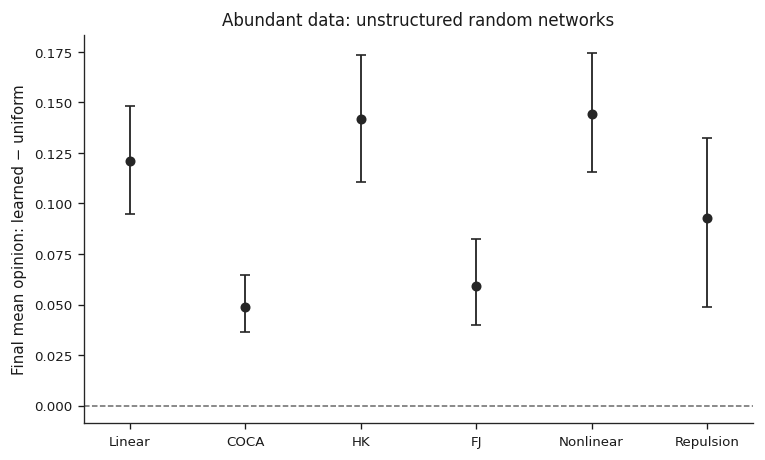

In [6]:
rows = unstructured_summary_df.copy()
means = rows["learned_minus_uniform_final_mean"].to_numpy(dtype=float)
lows = rows["learned_minus_uniform_final_ci_low"].to_numpy(dtype=float)
highs = rows["learned_minus_uniform_final_ci_high"].to_numpy(dtype=float)
yerr = np.vstack([means - lows, highs - means])
labels = [DYNAMICS_LABELS[d] for d in rows["dynamics"]]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(rows))
ax.errorbar(
    x, means, yerr=yerr, fmt="o", markersize=5, linewidth=1.1, capsize=3,
    color=("0.15" if PLOT_STYLE == "paper_bw" else POLICY_STYLE["learned"]["color"]),
)
ax.axhline(0.0, color="0.4", linewidth=0.9, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Abundant data: unstructured random networks")
ax.margins(x=0.08)
save_figure(fig, "01_abundant_unstructured_all_dynamics_learned_minus_uniform")
plt.show()
plt.close(fig)


## Plot 2 — final policy performance on the matched unstructured benchmark

All four policies are evaluated on the same 25 environment instances per dynamics. Learned values are
first averaged across the three identifier seeds within each environment.


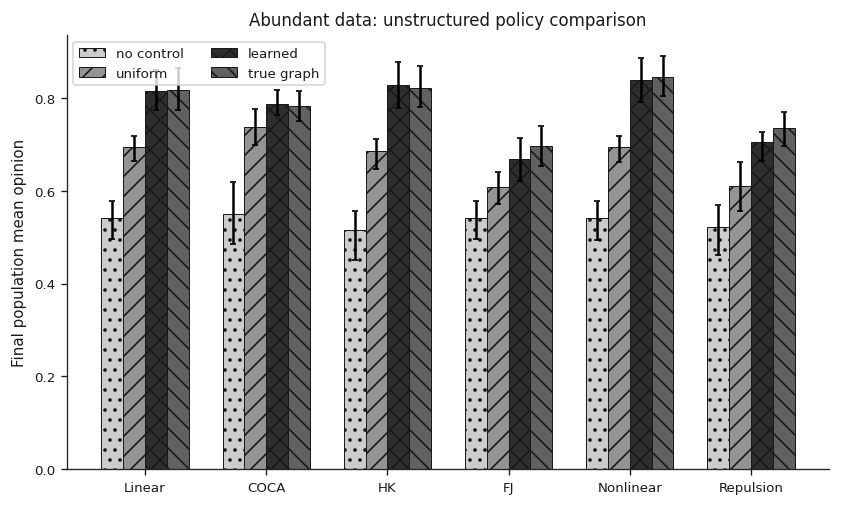

In [7]:
unstructured_env = env_level_df[env_level_df["scenario_class"] == "unstructured_random"].copy()
policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, ax = plt.subplots(figsize=(8.2, 4.7))
x = np.arange(len(DYNAMICS_ORDER))
width = 0.18

for p_index, (policy, column) in enumerate(policy_columns.items()):
    means, lows, highs = [], [], []
    for dynamics in DYNAMICS_ORDER:
        group = unstructured_env[unstructured_env["dynamics"] == dynamics]
        mean, low, high = crossed_bootstrap_ci(group, column, seed=20260824 + p_index)
        means.append(mean); lows.append(low); highs.append(high)
    means = np.asarray(means); lows = np.asarray(lows); highs = np.asarray(highs)
    yerr = np.vstack([means - lows, highs - means])
    style = POLICY_STYLE[policy]
    xpos = x + (p_index - 1.5) * width
    ax.bar(
        xpos, means, width=width, yerr=yerr, capsize=2, label=policy,
        color=style["color"], edgecolor="0.1", linewidth=0.6, hatch=style["hatch"],
    )

ax.set_xticks(x)
ax.set_xticklabels([DYNAMICS_LABELS[d] for d in DYNAMICS_ORDER])
ax.set_ylabel("Final population mean opinion")
ax.set_title("Abundant data: unstructured policy comparison")
ax.legend(ncol=2)
save_figure(fig, "02_abundant_unstructured_final_policy_comparison")
plt.show()
plt.close(fig)


## Plot 3 — structured-mechanism policy comparison

The structured benchmark should be read first in absolute policy space, not only as a learned-minus-uniform effect size. This grouped comparison shows all four policies for HK, FJ, and nonlinear influence using the same visual language as the generic benchmark.


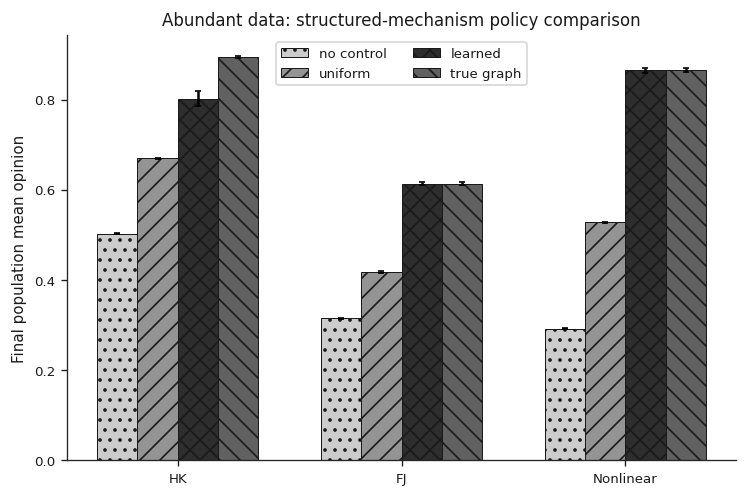

In [8]:
structured_env = env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].copy()

policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(STRUCTURED_ORDER))
width = 0.18

for p_index, (policy, column) in enumerate(policy_columns.items()):
    means, lows, highs = [], [], []
    for dynamics in STRUCTURED_ORDER:
        group = structured_env[structured_env["dynamics"] == dynamics]
        mean, low, high = student_t_mean_ci(group[column].to_numpy(dtype=float))
        means.append(mean); lows.append(low); highs.append(high)

    means = np.asarray(means)
    lows = np.asarray(lows)
    highs = np.asarray(highs)
    yerr = np.vstack([means - lows, highs - means])

    style = POLICY_STYLE[policy]
    ax.bar(
        x + (p_index - 1.5) * width,
        means,
        width=width,
        yerr=yerr,
        capsize=2,
        label=policy,
        color=style["color"],
        edgecolor="0.1",
        linewidth=0.6,
        hatch=style["hatch"],
    )

ax.set_xticks(x)
ax.set_xticklabels([DYNAMICS_LABELS[d] for d in STRUCTURED_ORDER])
ax.set_ylabel("Final population mean opinion")
ax.set_title("Abundant data: structured-mechanism policy comparison")
ax.legend(ncol=2)

save_figure(fig, "03_abundant_structured_final_policy_comparison")
plt.show()
plt.close(fig)


## Plot 4 — complete structured-family policy picture

Each panel resolves one structured dynamics into its three mechanism families and retains all four policies. This is intended as a high-information paper figure: it shows both whether the learned controller improves over uniform allocation and how that improvement relates to no control and the true-graph reference.


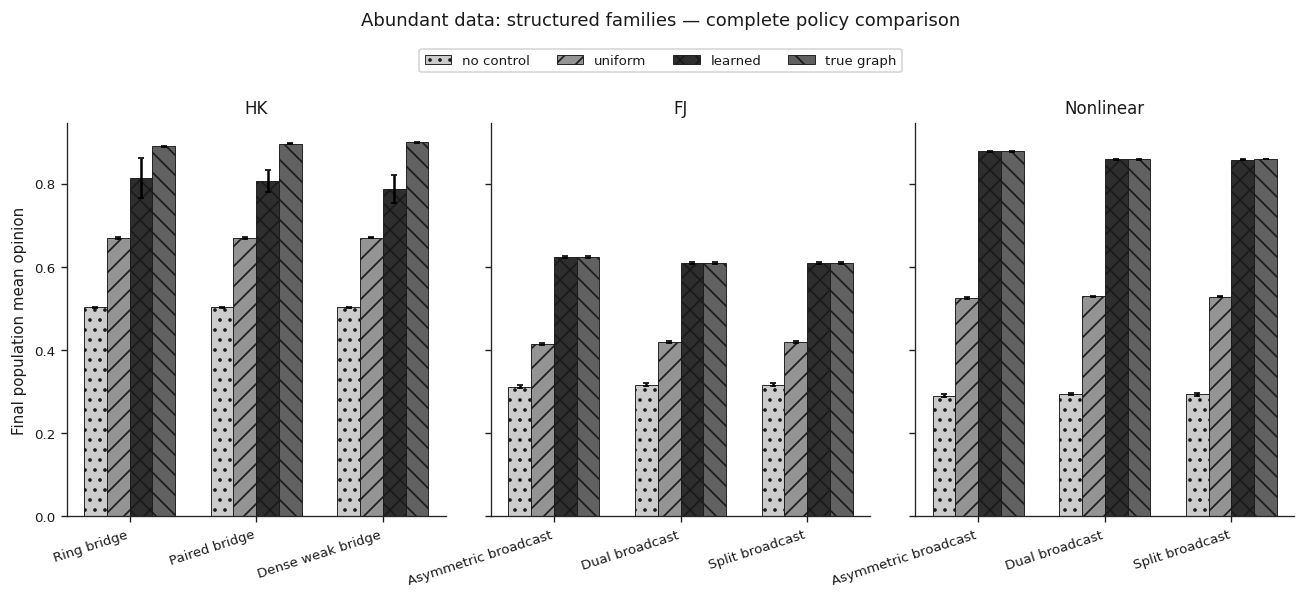

In [9]:
structured_env = env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].copy()

family_order = {
    "hegselmannkrause": ["ring_bridge", "paired_bridge", "dense_weak_bridge"],
    "friedkinjohnsen": ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"],
    "nonlinearinfluence": ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"],
}
policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, axes = plt.subplots(
    1, 3, figsize=(13.2, 4.25), sharey=True,
    gridspec_kw={"wspace": 0.12},
)
width = 0.18

for ax, dynamics in zip(axes, STRUCTURED_ORDER):
    families = family_order[dynamics]
    x = np.arange(len(families))

    for p_index, (policy, column) in enumerate(policy_columns.items()):
        means, lows, highs = [], [], []
        for family in families:
            group = structured_env[
                (structured_env["dynamics"] == dynamics)
                & (structured_env["family"] == family)
            ]
            mean, low, high = student_t_mean_ci(group[column].to_numpy(dtype=float))
            means.append(mean); lows.append(low); highs.append(high)

        means = np.asarray(means)
        lows = np.asarray(lows)
        highs = np.asarray(highs)
        yerr = np.vstack([means - lows, highs - means])
        style = POLICY_STYLE[policy]

        ax.bar(
            x + (p_index - 1.5) * width,
            means,
            width=width,
            yerr=yerr,
            capsize=2,
            label=policy,
            color=style["color"],
            edgecolor="0.1",
            linewidth=0.55,
            hatch=style["hatch"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [FAMILY_LABELS.get(f, f) for f in families],
        rotation=18,
        ha="right",
    )
    ax.set_title(DYNAMICS_LABELS[dynamics])

axes[0].set_ylabel("Final population mean opinion")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Abundant data: structured families — complete policy comparison", y=1.10)

save_figure(fig, "04_abundant_structured_family_policy_comparison")
plt.show()
plt.close(fig)


## Paper candidate — complete benchmark policy overview

This two-panel figure compresses the main absolute-performance result into one article-width figure: the six matched generic dynamics on the left and the three structured-mechanism dynamics on the right. It is a strong candidate for the main paper because the reader sees all policies, both benchmark classes, and the scale of the effects at once.


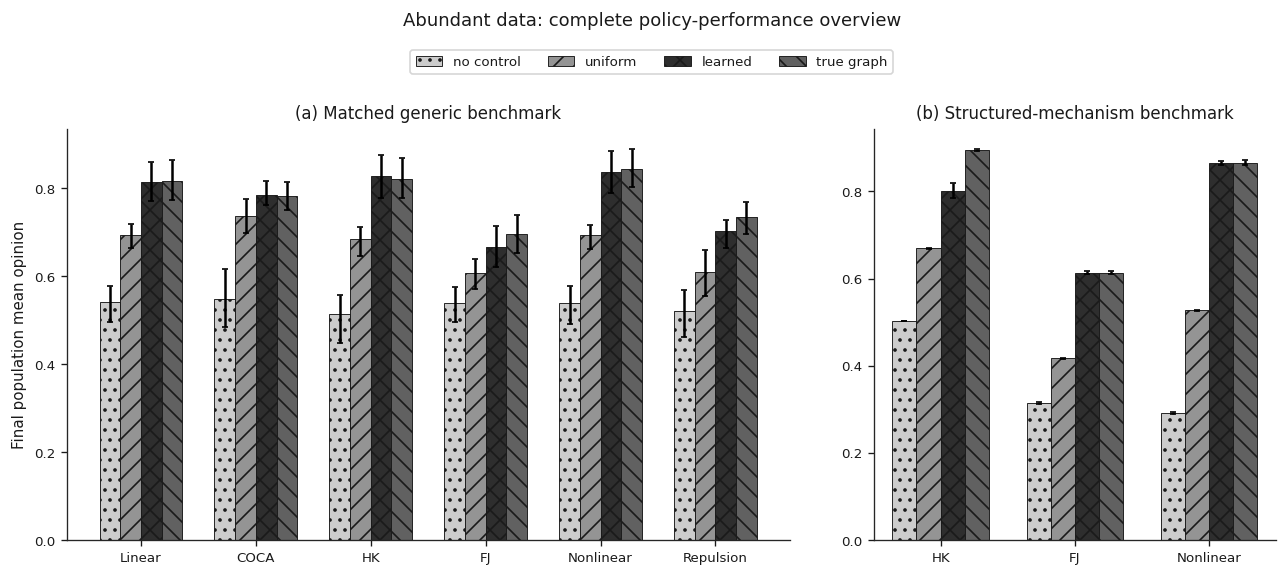

In [10]:
def draw_policy_bars(
    ax: plt.Axes,
    data: pd.DataFrame,
    dynamics_order: list[str],
    *,
    generic_crossed: bool,
    title: str,
) -> None:
    policy_columns = {
        "no control": "no_control_final_mean",
        "uniform": "uniform_final_mean",
        "learned": "learned_final_mean",
        "true graph": "true_graph_final_mean",
    }
    x = np.arange(len(dynamics_order))
    width = 0.18

    for p_index, (policy, column) in enumerate(policy_columns.items()):
        means, lows, highs = [], [], []
        for dynamics in dynamics_order:
            group = data[data["dynamics"] == dynamics]
            if generic_crossed:
                mean, low, high = crossed_bootstrap_ci(
                    group, column, seed=20260824 + p_index
                )
            else:
                mean, low, high = student_t_mean_ci(
                    group[column].to_numpy(dtype=float)
                )
            means.append(mean); lows.append(low); highs.append(high)

        means = np.asarray(means)
        lows = np.asarray(lows)
        highs = np.asarray(highs)
        yerr = np.vstack([means - lows, highs - means])
        style = POLICY_STYLE[policy]

        ax.bar(
            x + (p_index - 1.5) * width,
            means,
            width=width,
            yerr=yerr,
            capsize=1.8,
            label=policy,
            color=style["color"],
            edgecolor="0.1",
            linewidth=0.55,
            hatch=style["hatch"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([DYNAMICS_LABELS[d] for d in dynamics_order])
    ax.set_title(title)


fig, axes = plt.subplots(
    1, 2, figsize=(13.0, 4.45),
    gridspec_kw={"width_ratios": [1.8, 1.0], "wspace": 0.15},
)

draw_policy_bars(
    axes[0],
    env_level_df[env_level_df["scenario_class"] == "unstructured_random"],
    DYNAMICS_ORDER,
    generic_crossed=True,
    title="(a) Matched generic benchmark",
)
draw_policy_bars(
    axes[1],
    env_level_df[env_level_df["scenario_class"] == "structured_mechanism"],
    STRUCTURED_ORDER,
    generic_crossed=False,
    title="(b) Structured-mechanism benchmark",
)

axes[0].set_ylabel("Final population mean opinion")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Abundant data: complete policy-performance overview", y=1.10)

save_figure(fig, "04b_abundant_complete_policy_overview")
plt.show()
plt.close(fig)


## Paper candidate — paired effect-size overview

The absolute policy bars carry the complete performance picture. This compact companion summarizes the two paired contrasts that are easiest to interpret statistically: learned minus uniform and learned minus the true-graph reference. Generic intervals use the crossed topology/opinion bootstrap; structured intervals use Student-t over environments.


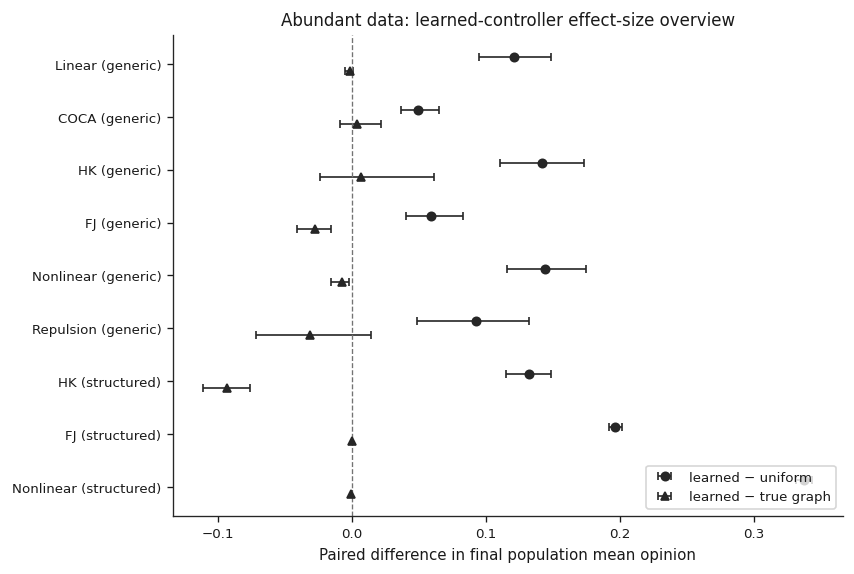

In [11]:
effect_rows = []
ordered_groups = [
    ("unstructured_random", d) for d in DYNAMICS_ORDER
] + [
    ("structured_mechanism", d) for d in STRUCTURED_ORDER
]

for scenario_class, dynamics in ordered_groups:
    group = env_level_df[
        (env_level_df["scenario_class"] == scenario_class)
        & (env_level_df["dynamics"] == dynamics)
    ]
    if group.empty:
        continue

    for contrast, column in [
        ("learned − uniform", "learned_minus_uniform_final"),
        ("learned − true graph", "learned_minus_true_graph_final"),
    ]:
        mean, low, high, method = mean_ci_for_group(group, column)
        effect_rows.append({
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            "contrast": contrast,
            "mean": mean,
            "ci_low": low,
            "ci_high": high,
            "ci_method": method,
        })

effect_df = pd.DataFrame(effect_rows)
effect_df.to_csv(RESULTS_DIR / "abundant_paired_effect_size_overview.csv", index=False)

labels = []
for scenario_class, dynamics in ordered_groups:
    if not (
        (effect_df["scenario_class"] == scenario_class)
        & (effect_df["dynamics"] == dynamics)
    ).any():
        continue
    suffix = "generic" if scenario_class == "unstructured_random" else "structured"
    labels.append(f"{DYNAMICS_LABELS[dynamics]} ({suffix})")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
y = np.arange(len(labels))
offset = 0.13

for contrast, marker, yoff in [
    ("learned − uniform", "o", -offset),
    ("learned − true graph", "^", offset),
]:
    sub = effect_df[effect_df["contrast"] == contrast].copy()
    means = sub["mean"].to_numpy(dtype=float)
    lows = sub["ci_low"].to_numpy(dtype=float)
    highs = sub["ci_high"].to_numpy(dtype=float)
    xerr = np.vstack([means - lows, highs - means])

    ax.errorbar(
        means,
        y + yoff,
        xerr=xerr,
        fmt=marker,
        capsize=2.5,
        linewidth=1.0,
        markersize=5,
        label=contrast,
        color=("0.15" if PLOT_STYLE == "paper_bw" else None),
    )

ax.axvline(0.0, color="0.45", linestyle="--", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Paired difference in final population mean opinion")
ax.set_title("Abundant data: learned-controller effect-size overview")
ax.legend(loc="lower right")

save_figure(fig, "04c_abundant_paired_effect_size_overview")
plt.show()
plt.close(fig)


## Prediction accuracy versus control improvement

This section quantifies, rather than only eyeballs, the relationship between predictive fit and control
quality. `model_over_identity < 1` means the learned one-step predictor improves on the identity
predictor. Spearman correlations are descriptive and are reported overall, by scenario class, and by
dynamics; the paired control comparison remains the primary analysis.


,group,n,rho,p_value
0,all,195,-0.07350,0.30720
1,structured_mechanism,45,-0.79170,0.00000
2,unstructured_random,150,-0.17984,0.02765
3,dynamics:coca,25,0.31077,0.13053
4,dynamics:friedkinjohnsen,40,0.90488,0.00000
5,dynamics:hegselmannkrause,40,0.18856,0.24394
6,dynamics:laplacian,25,0.50538,0.00997
7,dynamics:nonlinearinfluence,40,0.79925,0.00000
8,dynamics:repulsion,25,-0.14077,0.50211


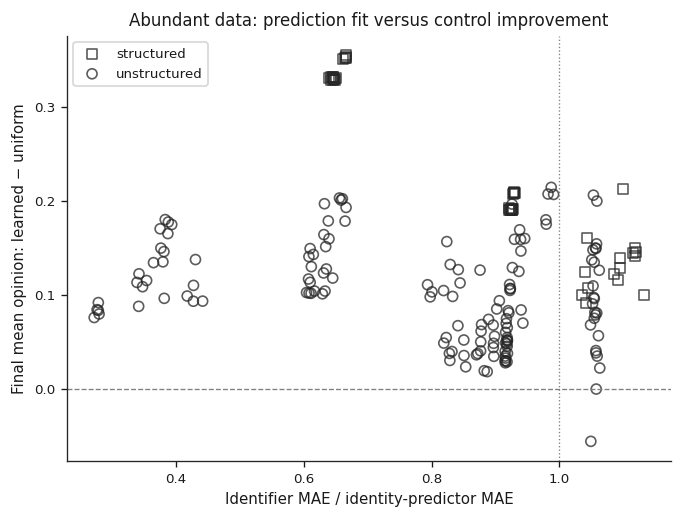

In [12]:
def spearman_row(label: str, group: pd.DataFrame, x_col: str, y_col: str) -> dict[str, Any]:
    subset = group[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(subset) < 3 or subset[x_col].nunique() < 2 or subset[y_col].nunique() < 2:
        return {"group": label, "n": len(subset), "rho": np.nan, "p_value": np.nan}
    result = spearmanr(subset[x_col], subset[y_col])
    return {"group": label, "n": len(subset), "rho": float(result.statistic), "p_value": float(result.pvalue)}

corr_rows = [spearman_row("all", env_level_df, "model_over_identity", "learned_minus_uniform_final")]
for scenario_class, group in env_level_df.groupby("scenario_class"):
    corr_rows.append(spearman_row(scenario_class, group, "model_over_identity", "learned_minus_uniform_final"))
for dynamics, group in env_level_df.groupby("dynamics"):
    corr_rows.append(spearman_row(f"dynamics:{dynamics}", group, "model_over_identity", "learned_minus_uniform_final"))
correlation_df = pd.DataFrame(corr_rows)
correlation_df.to_csv(RESULTS_DIR / "abundant_prediction_control_spearman.csv", index=False)
display(correlation_df.round(5))

fig, ax = plt.subplots(figsize=(6.5, 4.6))
marker_by_scenario = {"unstructured_random": "o", "structured_mechanism": "s"}
for scenario_class, group in env_level_df.groupby("scenario_class"):
    marker = marker_by_scenario[scenario_class]
    ax.scatter(
        group["model_over_identity"], group["learned_minus_uniform_final"],
        marker=marker, alpha=0.75,
        label=("unstructured" if scenario_class == "unstructured_random" else "structured"),
        facecolors=("none" if PLOT_STYLE == "paper_bw" else None),
        edgecolors=("0.15" if PLOT_STYLE == "paper_bw" else None),
    )
ax.axhline(0.0, color="0.5", linewidth=0.8, linestyle="--")
ax.axvline(1.0, color="0.5", linewidth=0.8, linestyle=":")
ax.set_xlabel("Identifier MAE / identity-predictor MAE")
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Abundant data: prediction fit versus control improvement")
ax.legend()
save_figure(fig, "05_abundant_fit_vs_control_gain")
plt.show()
plt.close(fig)


## Static graph recovery versus control improvement

The abundant learner also records direct errors in the static adjacency estimate and its corresponding
centrality vector. These diagnostics help separate “good prediction” from “recovering the particular
graph quantity used by the controller.”


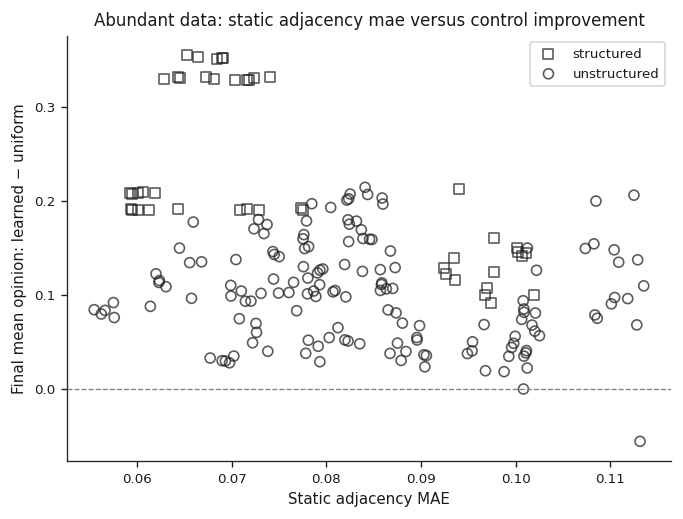

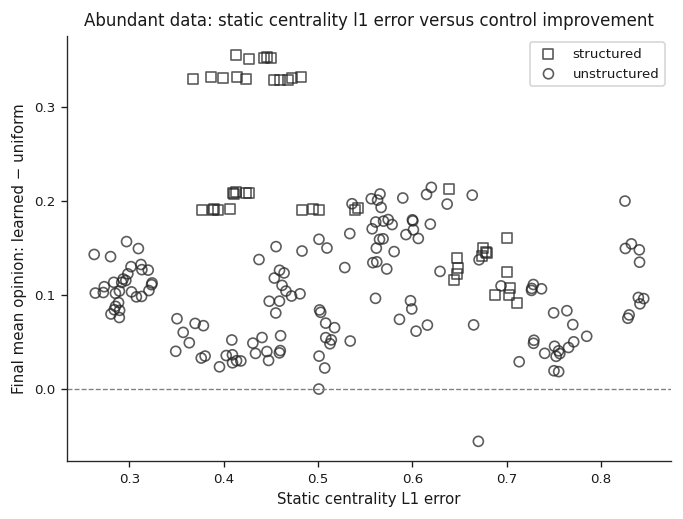

In [13]:
for metric, xlabel, stem in [
    ("A_MAE", "Static adjacency MAE", "06a_abundant_A_MAE_vs_control_gain"),
    ("v_static_L1", "Static centrality L1 error", "06b_abundant_centrality_error_vs_control_gain"),
]:
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    for scenario_class, group in env_level_df.groupby("scenario_class"):
        ax.scatter(
            group[metric], group["learned_minus_uniform_final"],
            marker=("o" if scenario_class == "unstructured_random" else "s"),
            alpha=0.75,
            label=("unstructured" if scenario_class == "unstructured_random" else "structured"),
            facecolors=("none" if PLOT_STYLE == "paper_bw" else None),
            edgecolors=("0.15" if PLOT_STYLE == "paper_bw" else None),
        )
    ax.axhline(0.0, color="0.5", linewidth=0.8, linestyle="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Final mean opinion: learned − uniform")
    ax.set_title(f"Abundant data: {xlabel.lower()} versus control improvement")
    ax.legend()
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)


## Structured mechanism targeting

For structured HK/FJ/nonlinear environments, the computation cache records the fraction of the
controlled budget assigned to the designated bridge/broadcast hub nodes. This directly tests whether
the learned controller concentrates intervention on the mechanism the benchmark was designed around.


,dynamics,family,n_environments,learned_mean,learned_ci_low,learned_ci_high,uniform_mean,uniform_ci_low,uniform_ci_high,true_graph_mean,true_graph_ci_low,true_graph_ci_high
0,friedkinjohnsen,asymmetric_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
1,friedkinjohnsen,dual_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
2,friedkinjohnsen,split_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
3,hegselmannkrause,dense_weak_bridge,5,0.50678,0.40824,0.60532,0.13333,0.13333,0.13333,1.0,1.0,1.0
4,hegselmannkrause,paired_bridge,5,0.56211,0.48669,0.63752,0.13333,0.13333,0.13333,1.0,1.0,1.0
5,hegselmannkrause,ring_bridge,5,0.61778,0.40351,0.83205,0.13333,0.13333,0.13333,1.0,1.0,1.0
6,nonlinearinfluence,asymmetric_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
7,nonlinearinfluence,dual_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
8,nonlinearinfluence,split_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0


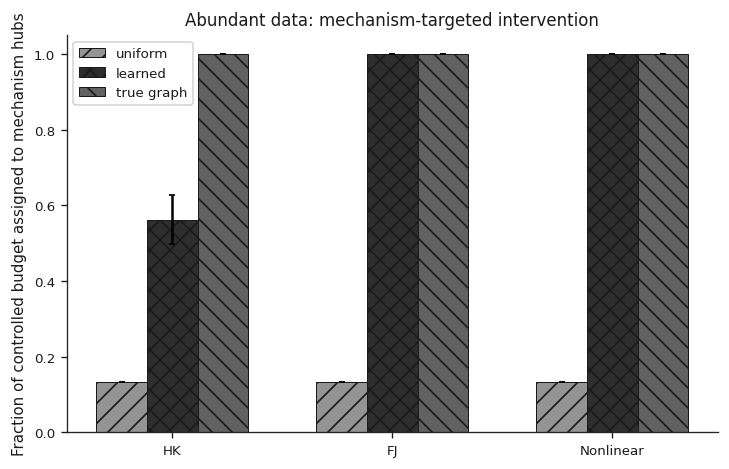

In [21]:
structured_env = env_level_df[env_level_df["scenario_class"] == "structured_mechanism"].copy()

hub_rows = []
for (dynamics, family), group in structured_env.groupby(["dynamics", "family"], sort=False):
    row = {"dynamics": dynamics, "family": family, "n_environments": len(group)}
    for label, col in [
        ("learned", "learned_hub_budget_fraction"),
        ("uniform", "uniform_hub_budget_fraction"),
        ("true_graph", "true_graph_hub_budget_fraction"),
    ]:
        if col in group.columns:
            mean, low, high = student_t_mean_ci(group[col].to_numpy())
            row[f"{label}_mean"] = mean
            row[f"{label}_ci_low"] = low
            row[f"{label}_ci_high"] = high
    hub_rows.append(row)

hub_targeting_df = pd.DataFrame(hub_rows)
hub_targeting_df.to_csv(RESULTS_DIR / "abundant_structured_hub_targeting.csv", index=False)
display(hub_targeting_df.round(5))

# Compact dynamics-level view for the manuscript.
hub_dyn_rows = []
for dynamics, group in structured_env.groupby("dynamics", sort=False):
    for policy_label, col in [
        ("uniform", "uniform_hub_budget_fraction"),
        ("learned", "learned_hub_budget_fraction"),
        ("true graph", "true_graph_hub_budget_fraction"),
    ]:
        mean, low, high = student_t_mean_ci(group[col].to_numpy())
        hub_dyn_rows.append({"dynamics": dynamics, "policy": policy_label, "mean": mean, "ci_low": low, "ci_high": high})
hub_dyn_df = pd.DataFrame(hub_dyn_rows)

fig, ax = plt.subplots(figsize=(7.0, 4.3))
x = np.arange(len(STRUCTURED_ORDER))
width = 0.23
for p_index, policy in enumerate(["uniform", "learned", "true graph"]):
    sub = hub_dyn_df[hub_dyn_df["policy"] == policy].set_index("dynamics").loc[STRUCTURED_ORDER].reset_index()
    means = sub["mean"].to_numpy(); lows = sub["ci_low"].to_numpy(); highs = sub["ci_high"].to_numpy()
    yerr = np.vstack([means - lows, highs - means])
    style = POLICY_STYLE[policy]
    ax.bar(
        x + (p_index - 1) * width, means, width=width, yerr=yerr, capsize=2,
        label=policy, color=style["color"], edgecolor="0.1", linewidth=0.6, hatch=style["hatch"],
    )
ax.set_xticks(x)
ax.set_xticklabels([DYNAMICS_LABELS[d] for d in STRUCTURED_ORDER])
ax.set_ylabel("Fraction of controlled budget assigned to mechanism hubs")
ax.set_title("Abundant data: mechanism-targeted intervention")
ax.legend(ncol=1, loc="upper left")
save_figure(fig, "07_abundant_structured_hub_targeting")
plt.show()
plt.close(fig)


## Abundant-data fit and runtime diagnostics

These are not primary outcome metrics, but they are useful for the reproducibility appendix and for
diagnosing whether a dynamics family is difficult because of model fit, static graph recovery, or
optimization instability.


In [15]:
diagnostic_columns = [
    "train_pairs_total", "fit_elapsed_s", "fit_steps_run", "train_mae", "identity_mae",
    "model_over_identity", "A_MAE", "A_Fro", "v_static_L1",
]
fit_diagnostics_df = (
    learned_df.groupby(["scenario_class", "dynamics"], as_index=False)[diagnostic_columns]
    .agg(["mean", "std"])
)
fit_diagnostics_df.to_csv(RESULTS_DIR / "abundant_fit_diagnostics_by_scenario_dynamics.csv")
display(fit_diagnostics_df.round(5))

print("Training pairs per learned run:", sorted(learned_df["train_pairs_total"].dropna().unique().tolist()))
print("Mean fit time [s]:", round(float(learned_df["fit_elapsed_s"].mean()), 3))
print("Total recorded fit time [min]:", round(float(learned_df["fit_elapsed_s"].sum() / 60.0), 2))
print("Fit stop reasons:")
display(learned_df["fit_stop_reason"].value_counts(dropna=False).rename_axis("reason").reset_index(name="count"))


scenario_class            dynamics train_pairs_total      fit_elapsed_s          fit_steps_run      train_mae          identity_mae          model_over_identity             A_MAE             A_Fro          v_static_L1         
                                                         mean  std          mean      std          mean  std      mean      std         mean      std                mean      std     mean      std     mean      std        mean      std
0  structured_mechanism     friedkinjohnsen            2500.0  0.0      10.21192  0.17634        1000.0  0.0   0.03384  0.00449      0.03654  0.00491             0.92623  0.00276  0.06509  0.00687  1.58693  0.27045     0.44005  0.05570
1  structured_mechanism    hegselmannkrause            2500.0  0.0      10.25405  0.24346        1000.0  0.0   0.00605  0.00035      0.00558  0.00035             1.08527  0.03425  0.09711  0.00338  2.83039  0.13047     0.67560  0.02724
2  structured_mechanism  nonlinearinfluence            2500.0  0.0       9.09820  2.26894        1000.0  0.0   0.00896  0.00023      0.01374  0.00033             0.65211  0.00974  0.06838  0.00331  1.65474  0.19085     0.43374  0.03458
3   unstructured_random                coca            2500.0  0.0      10.52479  0.33806        1000.0  0.0   0.00313  0.00025      0.00360  0.00019             0.86934  0.02943  0.09494  0.00559  2.35204  0.29001     0.59138  0.15525
4   unstructured_random     friedkinjohnsen            2500.0  0.0      10.42881  0.27853        1000.0  0.0   0.04515  0.00553      0.04916  0.00597             0.91832  0.00262  0.07764  0.00671  2.02675  0.29682     0.54953  0.16609
5   unstructured_random    hegselmannkrause            2500.0  0.0      10.41442  0.34015        1000.0  0.0   0.01399  0.00132      0.01549  0.00059             0.90182  0.06669  0.08353  0.00301  2.12231  0.21494     0.46857  0.13617
6   unstructured_random           laplacian            2500.0  0.0      10.67652  0.53957        1000.0  0.0   0.00377  0.00061      0.01037  0.00028             0.36258  0.05232  0.06576  0.00646  1.74378  0.29526     0.43139  0.12722
7   unstructured_random  nonlinearinfluence            2500.0  0.0      10.63726  0.22352        1000.0  0.0   0.00914  0.00061      0.01448  0.00055             0.63039  0.01956  0.07793  0.00378  1.95678  0.24451     0.43516  0.13369
8   unstructured_random           repulsion            2500.0  0.0      10.44029  0.18347        1000.0  0.0   0.00486  0.00047      0.00461  0.00046             1.05599  0.00758  0.10694  0.00499  2.60151  0.29325     0.66103  0.16124

Training pairs per learned run: [2500.0]
Mean fit time [s]: 10.367
Total recorded fit time [min]: 101.08
Fit stop reasons:


,reason,count
0,max_steps,585


## Cached learned-rollout loader

The abundant experiment persisted full **learned** rollouts, model states, and learned graph artifacts.
The three baseline policies were cached as exact summary rows only, so this notebook does not fabricate
baseline trajectory files. Headline baseline comparisons above are unaffected.


In [16]:
T_CAMPAIGN = 0.5
T_S = 0.1
TARGET = 1.0


def load_learned_rollout(environment_id: str, learning_seed: int) -> dict[str, Any]:
    path = ENV_CACHE[environment_id] / f"learned_seed_{int(learning_seed):02d}_rollout.npz"
    if not path.exists():
        raise FileNotFoundError(path)
    arrays = np.load(path, allow_pickle=False)
    inter_keys = sorted(key for key in arrays.files if key.startswith("intermediate__"))
    return {
        "policy": "learned_abundant_nonlinear",
        "states": np.asarray(arrays["states"], dtype=float),
        "actions": np.asarray(arrays["actions"], dtype=float),
        "rewards": np.asarray(arrays["rewards"], dtype=float),
        "A_hat": np.asarray(arrays["A_hat"], dtype=float),
        "v_hat_static": np.asarray(arrays["v_hat_static"], dtype=float),
        "intermediate_states_list": [np.asarray(arrays[key], dtype=float) for key in inter_keys],
    }


def fine_trajectory(rollout: dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    times = [0.0]
    states = [np.asarray(rollout["states"][0], dtype=float)]
    for campaign, inter in enumerate(rollout["intermediate_states_list"]):
        inter = np.asarray(inter, dtype=float)
        t0 = campaign * T_CAMPAIGN
        times.append(t0)
        states.append(inter[0])
        for step in range(1, len(inter)):
            times.append(t0 + step * T_S)
            states.append(inter[step])
    return np.asarray(times, dtype=float), np.asarray(states, dtype=float)


def representative_learning_seed(environment_id: str) -> int:
    rows = learned_df[learned_df["environment_id"] == environment_id].copy()
    median_value = float(rows["mean_end"].median())
    idx = (rows["mean_end"] - median_value).abs().idxmin()
    return int(rows.loc[idx, "learning_seed"])


CANONICAL_UNSTRUCTURED = {
    dynamics: f"unstructured__{dynamics}__topo03__x00" for dynamics in DYNAMICS_ORDER
}
CANONICAL_STRUCTURED = {
    "hegselmannkrause": "structured__hegselmannkrause__ring_bridge__env00",
    "friedkinjohnsen": "structured__friedkinjohnsen__asymmetric_broadcast__env00",
    "nonlinearinfluence": "structured__nonlinearinfluence__asymmetric_broadcast__env00",
}

for environment_id in [*CANONICAL_UNSTRUCTURED.values(), *CANONICAL_STRUCTURED.values()]:
    if environment_id not in ENV_CACHE:
        raise RuntimeError(f"Canonical environment missing: {environment_id}")

print("Canonical learned rollout loader ready.")


Canonical learned rollout loader ready.


## Plot 8 — canonical learned mean trajectories

Representative environments are fixed by seed, not selected after inspecting the outcome. Within each
environment, the displayed learning seed is the seed whose final outcome is closest to the three-seed
median.


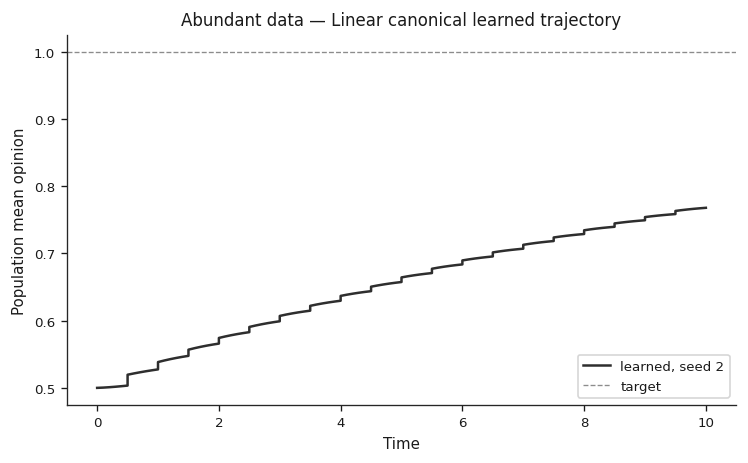

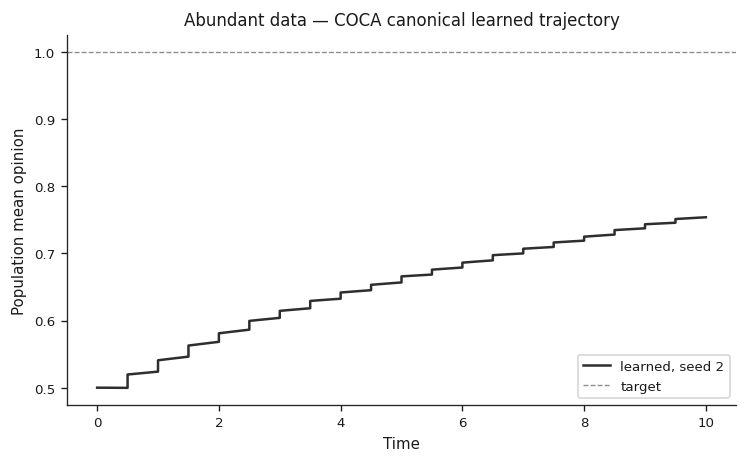

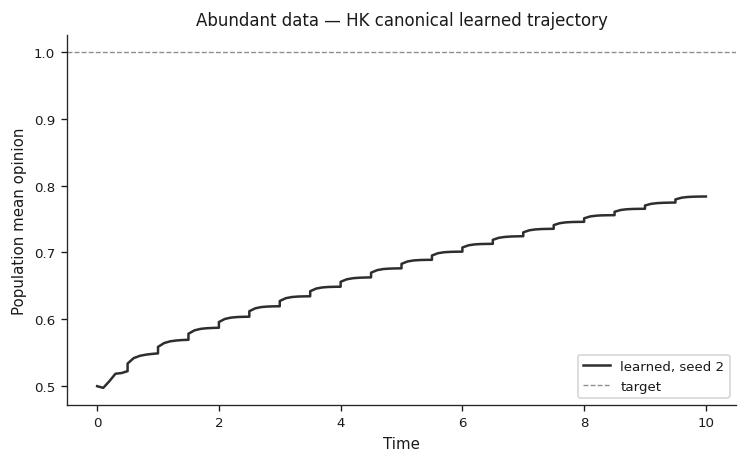

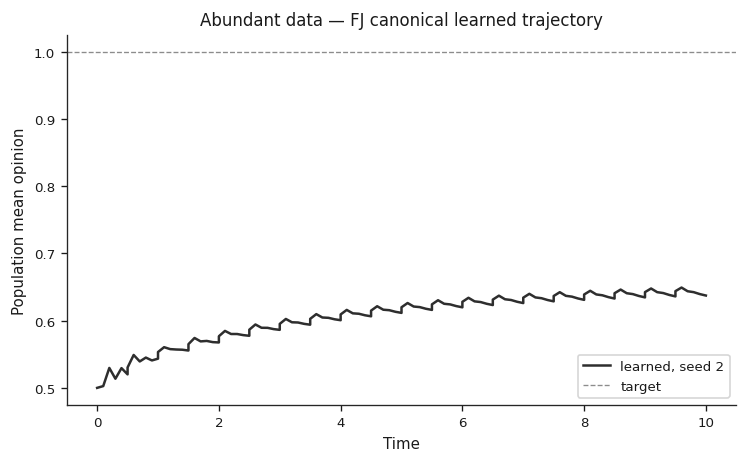

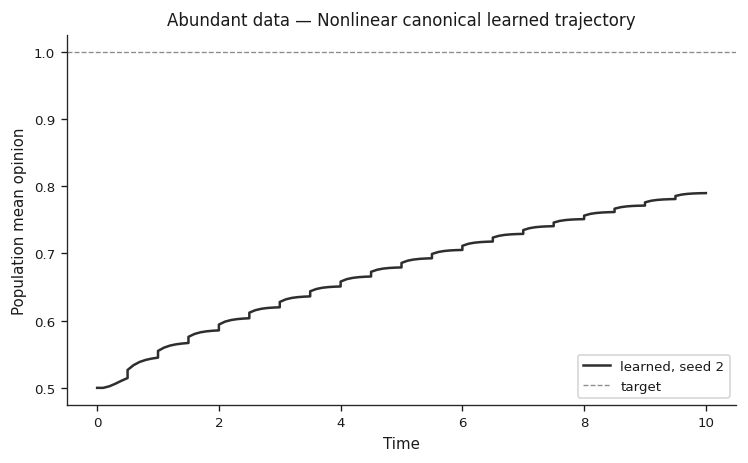

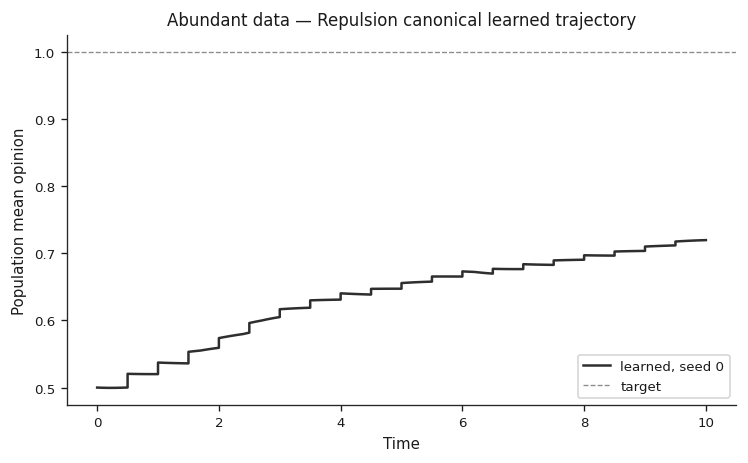

In [17]:
for dynamics in DYNAMICS_ORDER:
    environment_id = CANONICAL_UNSTRUCTURED[dynamics]
    seed = representative_learning_seed(environment_id)
    rollout = load_learned_rollout(environment_id, seed)
    times, states = fine_trajectory(rollout)
    mean_path = states.mean(axis=1)

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    ax.plot(times, mean_path, label=f"learned, seed {seed}", linewidth=1.5, color=POLICY_STYLE["learned"]["color"])
    ax.axhline(TARGET, color="0.55", linestyle="--", linewidth=0.8, label="target")
    ax.set_xlabel("Time")
    ax.set_ylabel("Population mean opinion")
    ax.set_title(f"Abundant data — {DYNAMICS_LABELS[dynamics]} canonical learned trajectory")
    ax.legend()
    save_figure(fig, f"08_abundant_canonical_mean_trajectory_{dynamics}")
    plt.show()
    plt.close(fig)


## Plot 9 — learned action heatmaps for canonical structured cases

These heatmaps expose where the abundant-data controller actually spends its budget across campaigns.
Campaign 0 is passive by design.


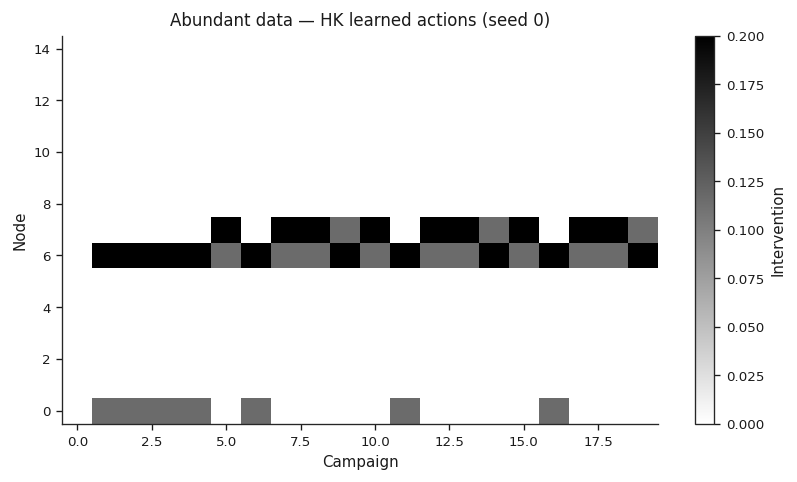

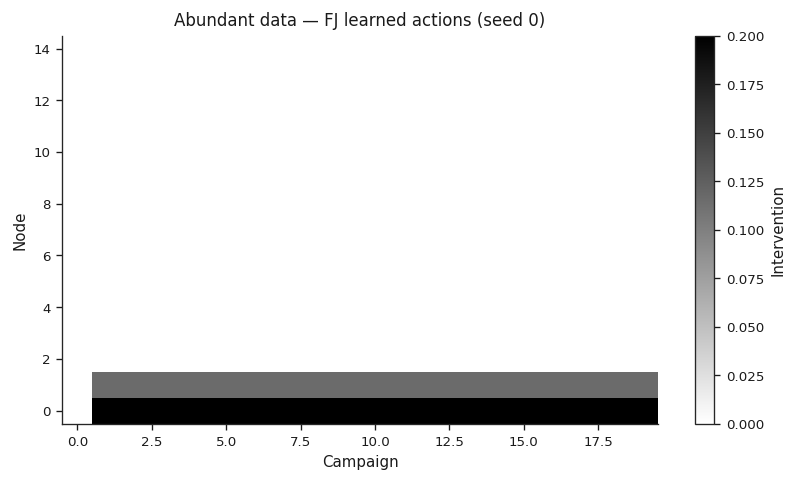

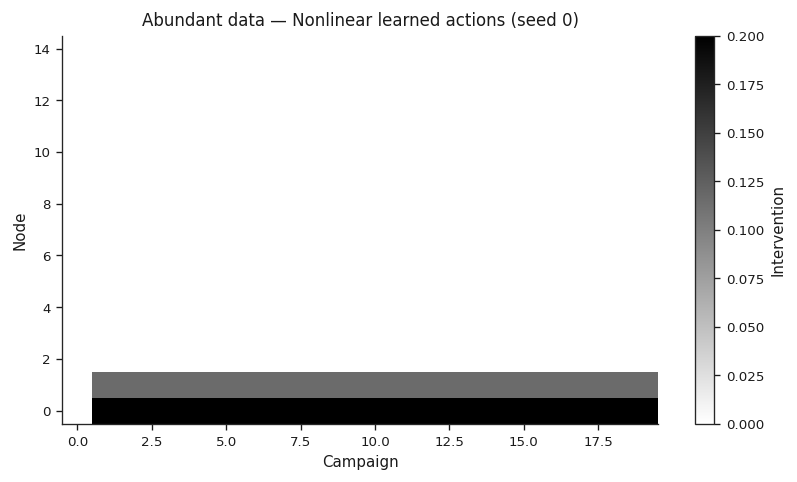

In [18]:
for dynamics, environment_id in CANONICAL_STRUCTURED.items():
    seed = representative_learning_seed(environment_id)
    rollout = load_learned_rollout(environment_id, seed)
    actions = np.asarray(rollout["actions"], dtype=float)

    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    image = ax.imshow(actions.T, aspect="auto", origin="lower", interpolation="nearest", cmap="gray_r")
    ax.set_xlabel("Campaign")
    ax.set_ylabel("Node")
    ax.set_title(f"Abundant data — {DYNAMICS_LABELS[dynamics]} learned actions (seed {seed})")
    fig.colorbar(image, ax=ax, label="Intervention")
    save_figure(fig, f"09_abundant_structured_action_heatmap_{dynamics}")
    plt.show()
    plt.close(fig)


## Recommended paper-figure shortlist

For a space-constrained article, the most information-dense outputs are:

1. **Complete policy-performance overview** (`04b_abundant_complete_policy_overview`): one two-panel figure covering all six generic dynamics and the three structured dynamics with all four policies.
2. **Structured-family complete comparison** (`04_abundant_structured_family_policy_comparison`): one three-panel figure covering all nine mechanism families with all four policies.
3. **Mechanism-targeted intervention** (`07_abundant_structured_hub_targeting`): use when the paper needs to explain *why* the learned controller succeeds, rather than only reporting final performance.
4. **Paired effect-size overview** (`04c_abundant_paired_effect_size_overview`): compact statistical companion if space permits or for supplementary material.

The individual effect-size, trajectory, graph-recovery, and heatmap plots remain useful diagnostics and can support the appendix/supplement without all appearing in the main text.


## Paper-ready tables

This section exports a standardized set of manuscript-facing tables using the same core schema as the single-shot notebook. The primary table preserves the **complete absolute policy picture** (no control, uniform, learned, and true-graph reference) together with paired controller effects. Additional tables preserve structured-family detail, trajectory-level effects, identification/graph-recovery quality, prediction-versus-control correlations, and mechanism-targeting behavior.

For the generic $5\times5$ benchmark, confidence intervals use the crossed topology/opinion bootstrap defined above. Structured environment and family intervals use Student-$t$ intervals over independent environment realizations.

In [19]:
PAPER_TABLE_DIR = RESULTS_DIR / "paper_tables"
PAPER_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _ci_fields(group: pd.DataFrame, value_col: str, prefix: str) -> dict[str, Any]:
    mean, low, high, method = mean_ci_for_group(group, value_col)
    return {
        f"{prefix}_mean": mean,
        f"{prefix}_ci_low": low,
        f"{prefix}_ci_high": high,
        f"{prefix}_ci_method": method,
    }


def _complete_performance_row(
    group: pd.DataFrame,
    *,
    scenario_class: str,
    dynamics: str,
    family: str | None = None,
) -> dict[str, Any]:
    row: dict[str, Any] = {
        "regime": "abundant",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "family": family,
        "n_environments": int(len(group)),
    }

    for label, col in [
        ("no_control", "no_control_final_mean"),
        ("uniform", "uniform_final_mean"),
        ("learned", "learned_final_mean"),
        ("true_graph", "true_graph_final_mean"),
        ("learned_minus_uniform", "learned_minus_uniform_final"),
        ("learned_minus_true_graph", "learned_minus_true_graph_final"),
        ("learned_minus_no_control", "learned_minus_no_control_final"),
        ("true_graph_minus_uniform", "true_graph_minus_uniform_final"),
    ]:
        row.update(_ci_fields(group, col, label))

    row["environment_win_rate_vs_uniform"] = float(
        (group["learned_minus_uniform_final"] > 0).mean()
    )
    row["environment_win_rate_vs_true_graph"] = float(
        (group["learned_minus_true_graph_final"] > 0).mean()
    )
    row["mean_learning_seed_std_final"] = float(group["learned_final_mean_seed_std"].mean())
    row["mean_prediction_mae_ratio"] = float(group["model_over_identity"].mean())
    return row


# ---------------------------------------------------------------------------
# 1) Complete absolute performance + paired effects by dynamics/scenario.
# ---------------------------------------------------------------------------
performance_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    performance_rows.append(
        _complete_performance_row(
            group,
            scenario_class=scenario_class,
            dynamics=dynamics,
        )
    )
paper_policy_performance_df = pd.DataFrame(performance_rows)
scenario_order = {"unstructured_random": 0, "structured_mechanism": 1}
dynamics_order_map = {d: i for i, d in enumerate(DYNAMICS_ORDER + STRUCTURED_ORDER)}
paper_policy_performance_df["_scenario_order"] = paper_policy_performance_df["scenario_class"].map(scenario_order)
paper_policy_performance_df["_dynamics_order"] = paper_policy_performance_df["dynamics"].map(dynamics_order_map)
paper_policy_performance_df = (
    paper_policy_performance_df
    .sort_values(["_scenario_order", "_dynamics_order"])
    .drop(columns=["_scenario_order", "_dynamics_order"])
    .reset_index(drop=True)
)
paper_policy_performance_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_policy_performance_by_dynamics.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 2) Complete structured-family performance (all four policies + effects).
# ---------------------------------------------------------------------------
structured_family_rows = []
for (dynamics, family), group in env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].groupby(["dynamics", "family"], sort=False):
    structured_family_rows.append(
        _complete_performance_row(
            group,
            scenario_class="structured_mechanism",
            dynamics=dynamics,
            family=family,
        )
    )
paper_structured_family_df = pd.DataFrame(structured_family_rows)
paper_structured_family_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_structured_families.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 3) Paired effects, including trajectory-level improvement.
# ---------------------------------------------------------------------------
paired_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    row = {
        "regime": "abundant",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "n_environments": int(len(group)),
    }
    row.update(_ci_fields(group, "learned_minus_uniform_final", "learned_minus_uniform_final"))
    row.update(_ci_fields(group, "learned_minus_uniform_trajectory", "learned_minus_uniform_path"))
    row.update(_ci_fields(group, "learned_minus_true_graph_final", "learned_minus_true_graph_final"))
    row["environment_win_rate_vs_uniform"] = float(
        (group["learned_minus_uniform_final"] > 0).mean()
    )
    row["environment_win_rate_vs_true_graph"] = float(
        (group["learned_minus_true_graph_final"] > 0).mean()
    )
    paired_rows.append(row)
paper_paired_effects_df = pd.DataFrame(paired_rows)
paper_paired_effects_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_paired_effects_by_dynamics.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 4) Identification and graph-recovery quality.
# ---------------------------------------------------------------------------
identification_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    row = {
        "regime": "abundant",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "n_environments": int(len(group)),
    }
    for prefix, col in [
        ("prediction_mae_ratio", "model_over_identity"),
        ("train_mae", "train_mae"),
        ("identity_mae", "identity_mae"),
        ("adjacency_mae", "A_MAE"),
        ("adjacency_frobenius", "A_Fro"),
        ("centrality_l1", "v_static_L1"),
        ("fit_elapsed_s", "fit_elapsed_s"),
        ("fit_steps", "fit_steps_run"),
        ("training_pairs", "train_pairs_total"),
        ("final_performance_seed_std", "learned_final_mean_seed_std"),
        ("trajectory_performance_seed_std", "learned_trajectory_seed_std"),
    ]:
        row.update(_ci_fields(group, col, prefix))
    identification_rows.append(row)
paper_identification_df = pd.DataFrame(identification_rows)
paper_identification_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_identification.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 5) Prediction quality versus control improvement.
#    Re-export the already-computed rank tests under the standardized paper name.
# ---------------------------------------------------------------------------
paper_prediction_control_corr_df = correlation_df.copy()
paper_prediction_control_corr_df.insert(0, "regime", "abundant")
paper_prediction_control_corr_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_prediction_control_spearman.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 6) Structured mechanism targeting, at family and dynamics level.
# ---------------------------------------------------------------------------
paper_targeting_df = hub_targeting_df.copy()
paper_targeting_df.insert(0, "regime", "abundant")
paper_targeting_df.insert(
    2,
    "dynamics_label",
    paper_targeting_df["dynamics"].map(DYNAMICS_LABELS),
)
paper_targeting_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_structured_targeting.csv",
    index=False,
)

paper_targeting_dynamics_df = hub_dyn_df.copy()
paper_targeting_dynamics_df.insert(0, "regime", "abundant")
paper_targeting_dynamics_df.insert(
    2,
    "dynamics_label",
    paper_targeting_dynamics_df["dynamics"].map(DYNAMICS_LABELS),
)
paper_targeting_dynamics_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_structured_targeting_by_dynamics.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# Display compact manuscript views and LaTeX previews.
# ---------------------------------------------------------------------------
main_cols = [
    "scenario_class", "dynamics_label", "n_environments",
    "no_control_mean", "uniform_mean", "learned_mean", "true_graph_mean",
    "learned_minus_uniform_mean", "learned_minus_uniform_ci_low", "learned_minus_uniform_ci_high",
    "environment_win_rate_vs_uniform", "learned_minus_true_graph_mean",
]
print("PAPER TABLE — abundant complete policy performance")
display(paper_policy_performance_df[main_cols].round(5))

print("\nPAPER TABLE — abundant structured families")
display(paper_structured_family_df[main_cols + ["family"]].round(5))

print("\nPAPER TABLE — abundant identification and graph recovery")
display(paper_identification_df.round(5))

print("\nPAPER TABLE — abundant prediction/control correlations")
display(paper_prediction_control_corr_df.round(5))

print("\nPAPER TABLE — abundant structured mechanism targeting")
display(paper_targeting_df.round(5))

print("\nLaTeX preview — abundant complete policy performance")
print(
    paper_policy_performance_df[main_cols]
    .round(4)
    .to_latex(index=False, escape=True)
)

paper_table_manifest_abundant = pd.DataFrame([
    {"file": "paper_table_abundant_policy_performance_by_dynamics.csv", "purpose": "Main absolute four-policy performance plus paired final effects"},
    {"file": "paper_table_abundant_structured_families.csv", "purpose": "All four policies and paired effects for each of the nine structured families"},
    {"file": "paper_table_abundant_paired_effects_by_dynamics.csv", "purpose": "Final and trajectory-level paired effects with win rates"},
    {"file": "paper_table_abundant_identification.csv", "purpose": "Prediction, graph recovery, training, runtime, and learning-seed diagnostics"},
    {"file": "paper_table_abundant_prediction_control_spearman.csv", "purpose": "Prediction-quality versus control-improvement rank correlations"},
    {"file": "paper_table_abundant_structured_targeting.csv", "purpose": "Mechanism-hub budget fractions by structured family"},
    {"file": "paper_table_abundant_structured_targeting_by_dynamics.csv", "purpose": "Mechanism-hub budget fractions aggregated by dynamics"},
])
paper_table_manifest_abundant.to_csv(
    PAPER_TABLE_DIR / "paper_table_abundant_manifest.csv", index=False
)
print("\nPaper tables written to:", PAPER_TABLE_DIR)
display(paper_table_manifest_abundant)


PAPER TABLE — abundant complete policy performance


,scenario_class,dynamics_label,n_environments,no_control_mean,uniform_mean,learned_mean,true_graph_mean,learned_minus_uniform_mean,learned_minus_uniform_ci_low,learned_minus_uniform_ci_high,environment_win_rate_vs_uniform,learned_minus_true_graph_mean
0,unstructured_random,Linear,25,0.54103,0.69365,0.81450,0.81645,0.12085,0.09496,0.14836,1.00,-0.00194
1,unstructured_random,COCA,25,0.54861,0.73654,0.78544,0.78185,0.04890,0.03642,0.06468,1.00,0.00358
2,unstructured_random,Repulsion,25,0.52092,0.61094,0.70360,0.73479,0.09266,0.04883,0.13227,0.92,-0.03119
3,unstructured_random,HK,25,0.51544,0.68555,0.82746,0.82106,0.14190,0.11082,0.17350,1.00,0.00640
4,unstructured_random,FJ,25,0.54037,0.60878,0.66774,0.69559,0.05895,0.04008,0.08262,1.00,-0.02785
5,unstructured_random,Nonlinear,25,0.54024,0.69313,0.83718,0.84473,0.14405,0.11532,0.17444,1.00,-0.00754
6,structured_mechanism,HK,15,0.50278,0.66980,0.80174,0.89542,0.13195,0.11523,0.14867,1.00,-0.09368
7,structured_mechanism,FJ,15,0.31478,0.41721,0.61368,0.61384,0.19647,0.19171,0.20124,1.00,-0.00016
8,structured_mechanism,Nonlinear,15,0.29227,0.52762,0.86503,0.86558,0.33741,0.33129,0.34354,1.00,-0.00054



PAPER TABLE — abundant structured families


,scenario_class,dynamics_label,n_environments,no_control_mean,uniform_mean,learned_mean,true_graph_mean,learned_minus_uniform_mean,learned_minus_uniform_ci_low,learned_minus_uniform_ci_high,environment_win_rate_vs_uniform,learned_minus_true_graph_mean,family
0,structured_mechanism,FJ,5,0.31169,0.41459,0.62277,0.62277,0.20819,0.20693,0.20944,1.0,0.00000,asymmetric_broadcast
1,structured_mechanism,FJ,5,0.31635,0.41853,0.60912,0.60922,0.19059,0.18982,0.19135,1.0,-0.00010,dual_broadcast
2,structured_mechanism,FJ,5,0.31632,0.41851,0.60915,0.60953,0.19065,0.18959,0.19170,1.0,-0.00038,split_broadcast
3,structured_mechanism,HK,5,0.50302,0.67034,0.78686,0.89941,0.11652,0.08278,0.15026,1.0,-0.11255,dense_weak_bridge
4,structured_mechanism,HK,5,0.50266,0.66967,0.80566,0.89641,0.13599,0.11016,0.16182,1.0,-0.09075,paired_bridge
5,structured_mechanism,HK,5,0.50267,0.66938,0.81271,0.89044,0.14333,0.09462,0.19205,1.0,-0.07773,ring_bridge
6,structured_mechanism,Nonlinear,5,0.28941,0.52571,0.87813,0.87813,0.35242,0.35052,0.35432,1.0,-0.00000,asymmetric_broadcast
7,structured_mechanism,Nonlinear,5,0.29380,0.52864,0.85900,0.85924,0.33036,0.32901,0.33171,1.0,-0.00024,dual_broadcast
8,structured_mechanism,Nonlinear,5,0.29361,0.52851,0.85797,0.85935,0.32946,0.32780,0.33111,1.0,-0.00139,split_broadcast



PAPER TABLE — abundant identification and graph recovery


...

,regime,group,n,rho,p_value
0,abundant,all,195,-0.07350,0.30720
1,abundant,structured_mechanism,45,-0.79170,0.00000
2,abundant,unstructured_random,150,-0.17984,0.02765
3,abundant,dynamics:coca,25,0.31077,0.13053
4,abundant,dynamics:friedkinjohnsen,40,0.90488,0.00000
5,abundant,dynamics:hegselmannkrause,40,0.18856,0.24394
6,abundant,dynamics:laplacian,25,0.50538,0.00997
7,abundant,dynamics:nonlinearinfluence,40,0.79925,0.00000
8,abundant,dynamics:repulsion,25,-0.14077,0.50211



PAPER TABLE — abundant structured mechanism targeting


,regime,dynamics,dynamics_label,family,n_environments,learned_mean,learned_ci_low,learned_ci_high,uniform_mean,uniform_ci_low,uniform_ci_high,true_graph_mean,true_graph_ci_low,true_graph_ci_high
0,abundant,friedkinjohnsen,FJ,asymmetric_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
1,abundant,friedkinjohnsen,FJ,dual_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
2,abundant,friedkinjohnsen,FJ,split_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
3,abundant,hegselmannkrause,HK,dense_weak_bridge,5,0.50678,0.40824,0.60532,0.13333,0.13333,0.13333,1.0,1.0,1.0
4,abundant,hegselmannkrause,HK,paired_bridge,5,0.56211,0.48669,0.63752,0.13333,0.13333,0.13333,1.0,1.0,1.0
5,abundant,hegselmannkrause,HK,ring_bridge,5,0.61778,0.40351,0.83205,0.13333,0.13333,0.13333,1.0,1.0,1.0
6,abundant,nonlinearinfluence,Nonlinear,asymmetric_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
7,abundant,nonlinearinfluence,Nonlinear,dual_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0
8,abundant,nonlinearinfluence,Nonlinear,split_broadcast,5,1.00000,1.00000,1.00000,0.13333,0.13333,0.13333,1.0,1.0,1.0



LaTeX preview — abundant complete policy performance
\begin{tabular}{llrrrrrrrrrr}
\toprule
scenario\_class & dynamics\_label & n\_environments & no\_control\_mean & uniform\_mean & learned\_mean & true\_graph\_mean & learned\_minus\_uniform\_mean & learned\_minus\_uniform\_ci\_low & learned\_minus\_uniform\_ci\_high & environment\_win\_rate\_vs\_uniform & learned\_minus\_true\_graph\_mean \\
\midrule
unstructured\_random & Linear & 25 & 0.541000 & 0.693700 & 0.814500 & 0.816400 & 0.120900 & 0.095000 & 0.148400 & 1.000000 & -0.001900 \\
unstructured\_random & COCA & 25 & 0.548600 & 0.736500 & 0.785400 & 0.781900 & 0.048900 & 0.036400 & 0.064700 & 1.000000 & 0.003600 \\
unstructured\_random & Repulsion & 25 & 0.520900 & 0.610900 & 0.703600 & 0.734800 & 0.092700 & 0.048800 & 0.132300 & 0.920000 & -0.031200 \\
unstructured\_random & HK & 25 & 0.515400 & 0.685600 & 0.827500 & 0.821100 & 0.141900 & 0.110800 & 0.173500 & 1.000000 & 0.006400 \\
unstructured\_random & FJ & 25 & 0.540400 & 0.6

,file,purpose
0,paper_table_abundant_policy_performance_by_dyn...,Main absolute four-policy performance plus pai...
1,paper_table_abundant_structured_families.csv,All four policies and paired effects for each ...
2,paper_table_abundant_paired_effects_by_dynamic...,Final and trajectory-level paired effects with...
3,paper_table_abundant_identification.csv,"Prediction, graph recovery, training, runtime,..."
4,paper_table_abundant_prediction_control_spearm...,Prediction-quality versus control-improvement ...
5,paper_table_abundant_structured_targeting.csv,Mechanism-hub budget fractions by structured f...
6,paper_table_abundant_structured_targeting_by_d...,Mechanism-hub budget fractions aggregated by d...


## Final analysis audit

This final cell records the experiment shape and important invariants. If any assertion here fails,
do not copy numbers from the notebook into the manuscript until the cache discrepancy is resolved.


In [20]:
audit_rows = []

# Design counts.
audit_rows.append({"check": "distinct environments", "value": int(env_level_df["environment_id"].nunique()), "expected": 195})
audit_rows.append({"check": "learned seed runs", "value": int(len(learned_df)), "expected": 585})
audit_rows.append({"check": "baseline rows", "value": int(len(baseline_df)), "expected": 585})
audit_rows.append({"check": "combined rows", "value": int(len(combined_df)), "expected": 1170})
audit_rows.append({"check": "unstructured environments", "value": int((env_level_df["scenario_class"] == "unstructured_random").sum()), "expected": 150})
audit_rows.append({"check": "structured environments", "value": int((env_level_df["scenario_class"] == "structured_mechanism").sum()), "expected": 45})

# Abundant-data invariants.
train_pair_values = sorted(set(learned_df["train_pairs_total"].dropna().astype(int).tolist()))
audit_rows.append({"check": "unique training-pair counts", "value": str(train_pair_values), "expected": "[2500]"})
if "abundant_resets" in learned_df.columns:
    audit_rows.append({"check": "abundant resets", "value": str(sorted(set(learned_df["abundant_resets"].dropna().astype(int)))), "expected": "[100]"})
if "abundant_campaigns_per_reset" in learned_df.columns:
    audit_rows.append({"check": "collection campaigns/reset", "value": str(sorted(set(learned_df["abundant_campaigns_per_reset"].dropna().astype(int)))), "expected": "[5]"})

# Main count assertions.
assert env_level_df["environment_id"].nunique() == 195
assert len(learned_df) == 585
assert len(baseline_df) == 585
assert len(combined_df) == 1170
assert (env_level_df["scenario_class"] == "unstructured_random").sum() == 150
assert (env_level_df["scenario_class"] == "structured_mechanism").sum() == 45
assert train_pair_values == [2500]

# Complete generic 5x5 design for each dynamics.
for dynamics in DYNAMICS_ORDER:
    group = env_level_df[(env_level_df["scenario_class"] == "unstructured_random") & (env_level_df["dynamics"] == dynamics)]
    assert len(group) == 25
    assert group["topology_seed"].nunique() == 5
    assert group["opinion_seed"].nunique() == 5
    assert len(group[["topology_seed", "opinion_seed"]].drop_duplicates()) == 25

# Every structured family has five realizations.
structured_counts = (
    env_level_df[env_level_df["scenario_class"] == "structured_mechanism"]
    .groupby(["dynamics", "family"]).size()
)
assert len(structured_counts) == 9
assert structured_counts.eq(5).all()

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(RESULTS_DIR / "abundant_analysis_audit.csv", index=False)
display(audit_df)

print("\nAnalysis audit passed.")
print("Paper-ready outputs are in:", RESULTS_DIR)
print("Figures are in:", PLOT_DIR)


,check,value,expected
0,distinct environments,195,195
1,learned seed runs,585,585
2,baseline rows,585,585
3,combined rows,1170,1170
4,unstructured environments,150,150
5,structured environments,45,45
6,unique training-pair counts,[2500],[2500]
7,abundant resets,[100],[100]
8,collection campaigns/reset,[5],[5]



Analysis audit passed.
Paper-ready outputs are in: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed
Figures are in: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_24_abundant_all_dynamics_multitopology_multiseed\plots_paper_bw
